In [1]:
from matplotlib import pyplot as plt
# Use the style file defined in the repository route
plt.style.use('../../paper.mplstyle')
import h5py
import numpy as np

import sys
import os

parent_dir = os.path.abspath("..")

if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from plotting_utils import get_colors, plot_optimal_snr_match

In [2]:
premerger_days = [1, 4, 7, 14]
premerger_colours = get_colors(values=premerger_days, vmin=0.5, vmax=14)

In [3]:
# Get the truth times
import ldc.io.hdf5 as hdfio

input_data = '../../datasets/LDC2_sangria_hm_training.hdf'
mbhb_sky, _ = hdfio.load_array(input_data, name="sky/mbhb/cat")

# Collect the Fitting Factor Results

In [4]:
ff_results = {
    'optimal_snr': {},
    'match_cut': {
        signal_number: {}
        for signal_number in range(len(mbhb_sky))
    },
}
with h5py.File('results/optimal_snr_over_time.hdf', 'r') as osot_f:
    ff_results['cutoff_days'] = osot_f['cutoff_days'][:]
    ff_results['optimal_snr'] = {
        signal_number: osot_f[f'signal_{signal_number}']['optimal_snr'][:]
        for signal_number in range(len(mbhb_sky))
        if f'signal_{signal_number}' in osot_f
    }

    for signal_number in range(len(mbhb_sky)):
        if f'signal_{signal_number}' not in osot_f:
            continue
        for premerger_day in premerger_days:
            ff_results['match_cut'][signal_number][premerger_day] = \
                osot_f[f'signal_{signal_number}'][f'match_cut_{premerger_day}_days'][:]


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
Outputting to ../../paper/images/zero_latency_results/figure_X_opt_snr_match_signal_14.pdf


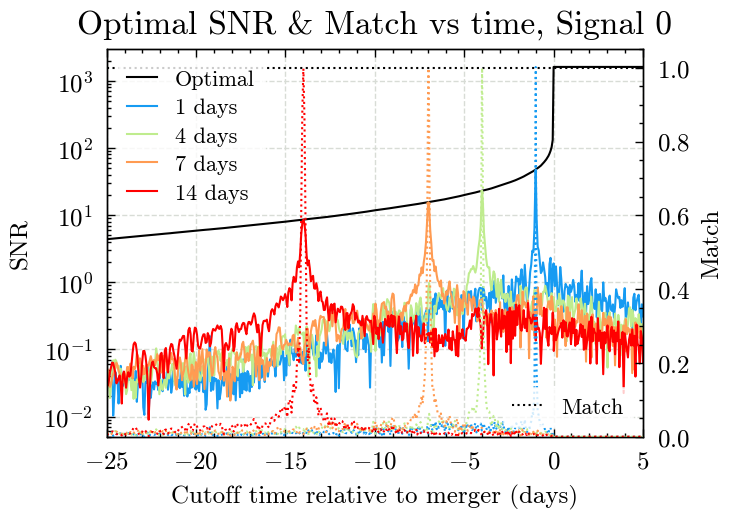

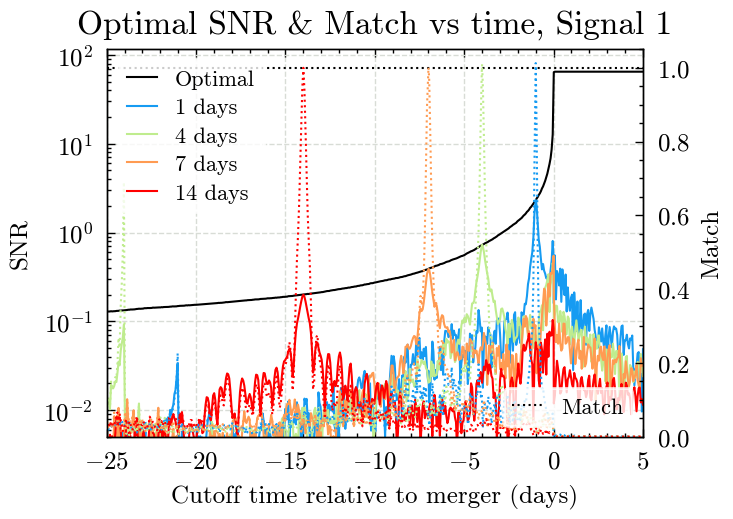

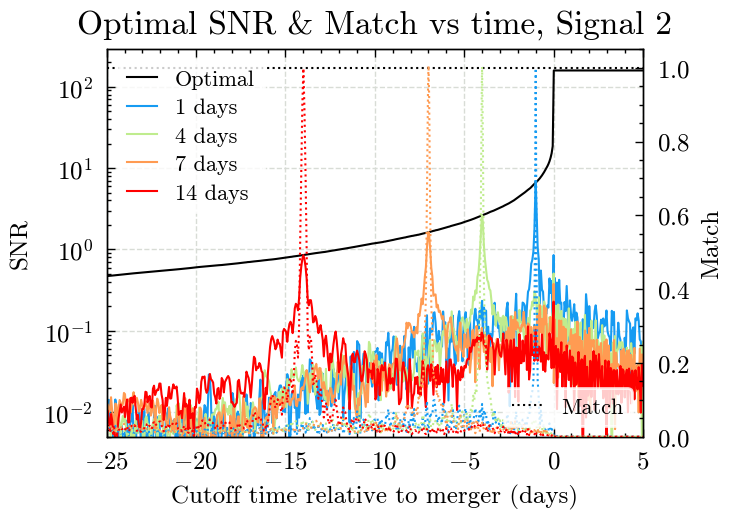

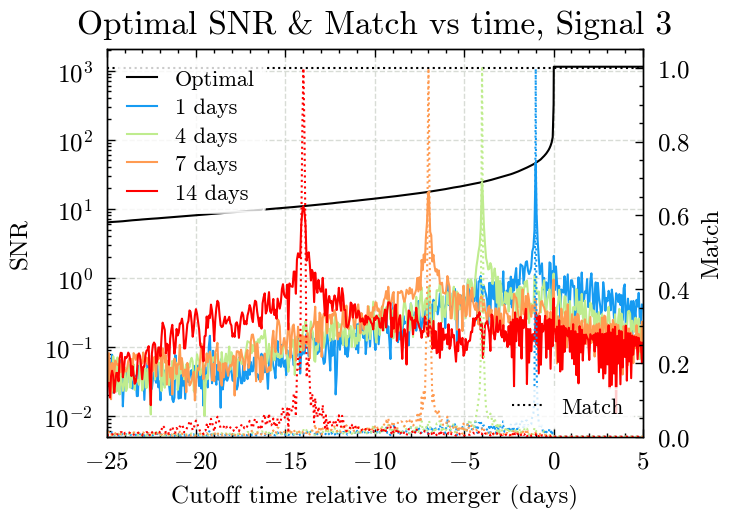

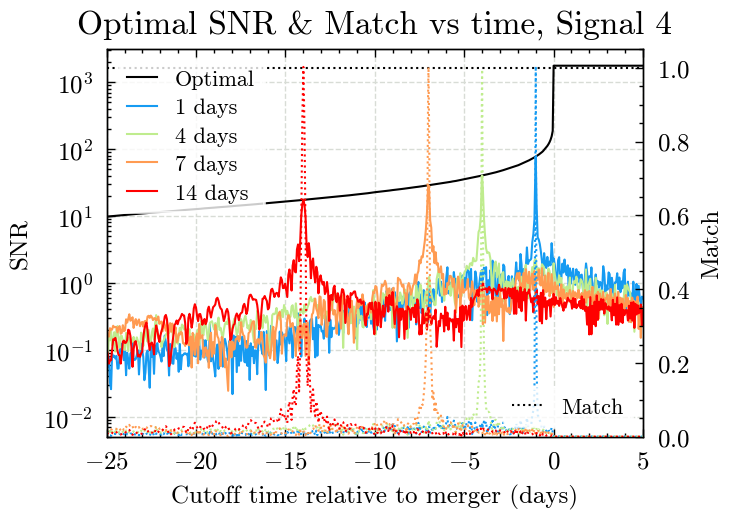

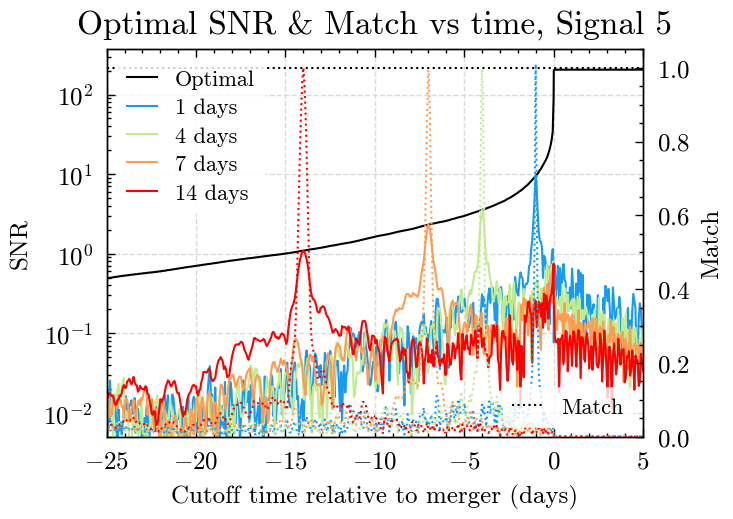

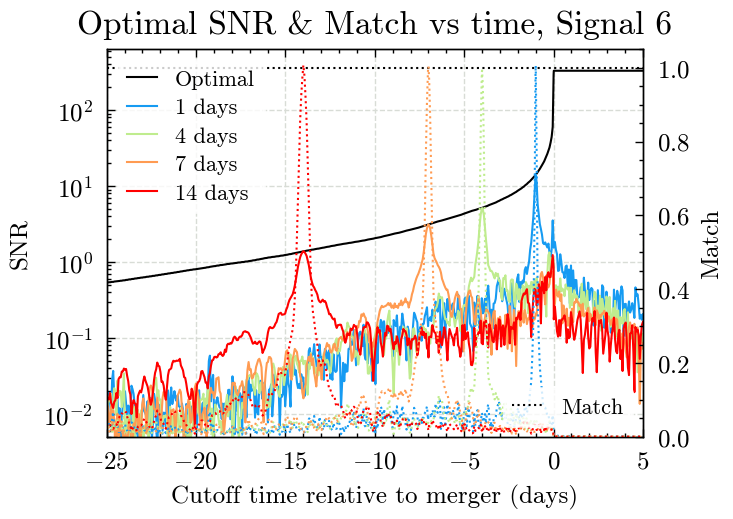

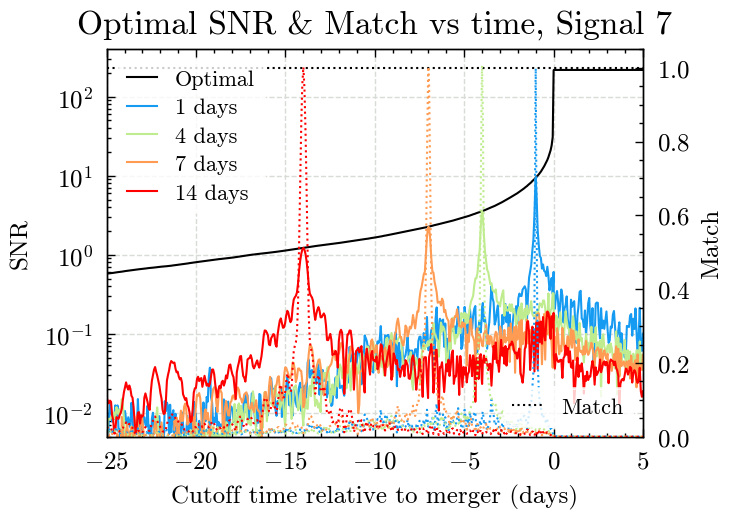

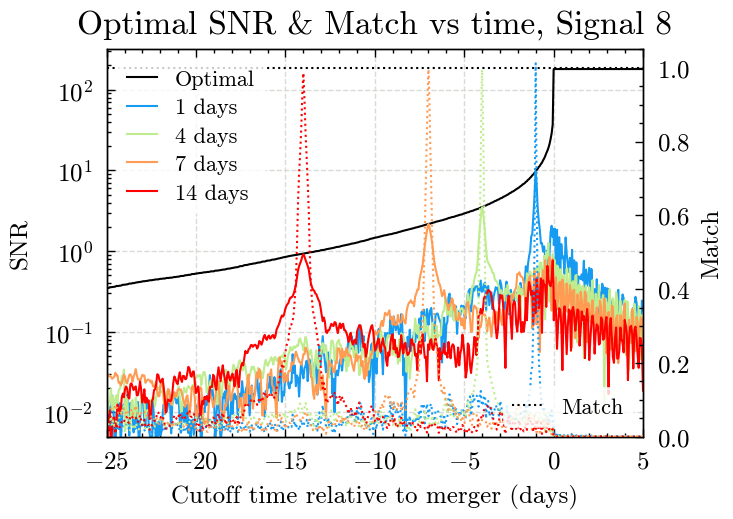

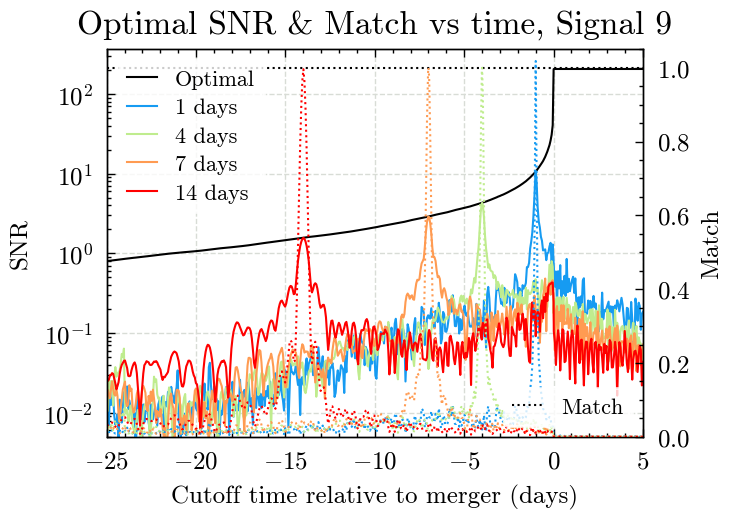

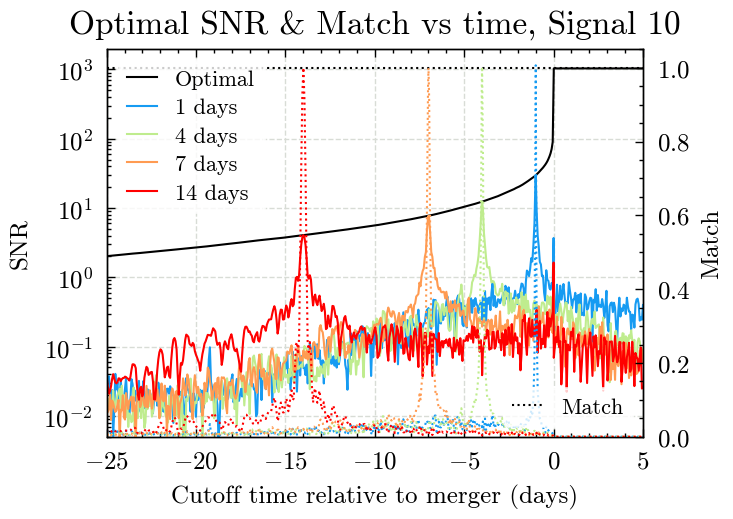

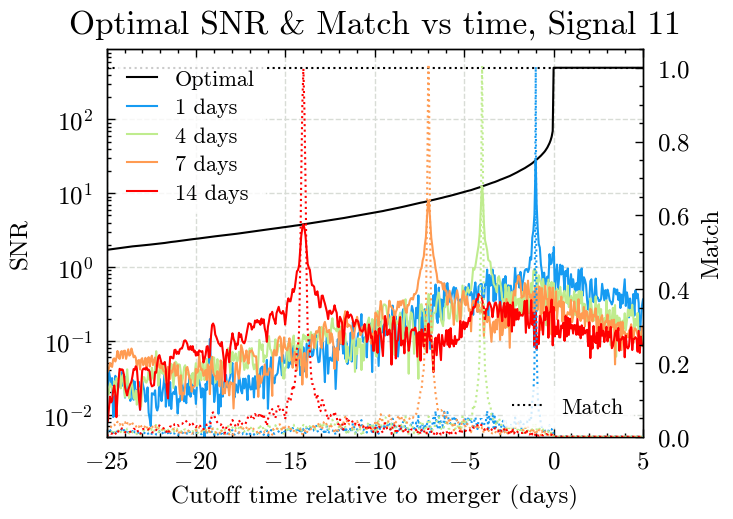

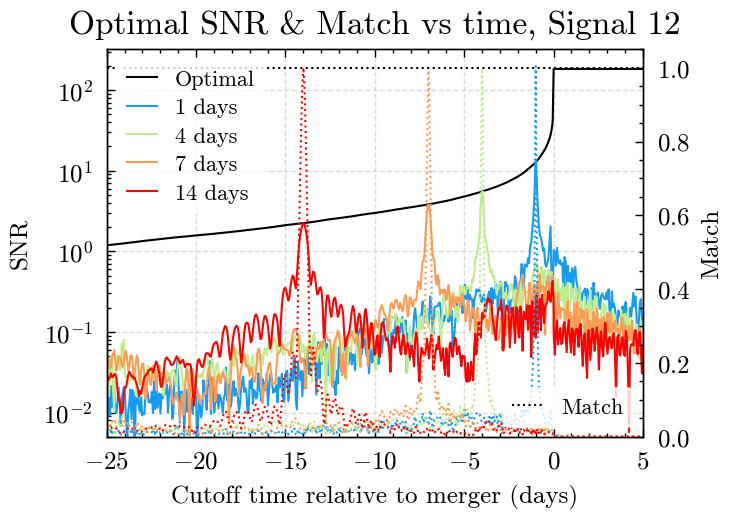

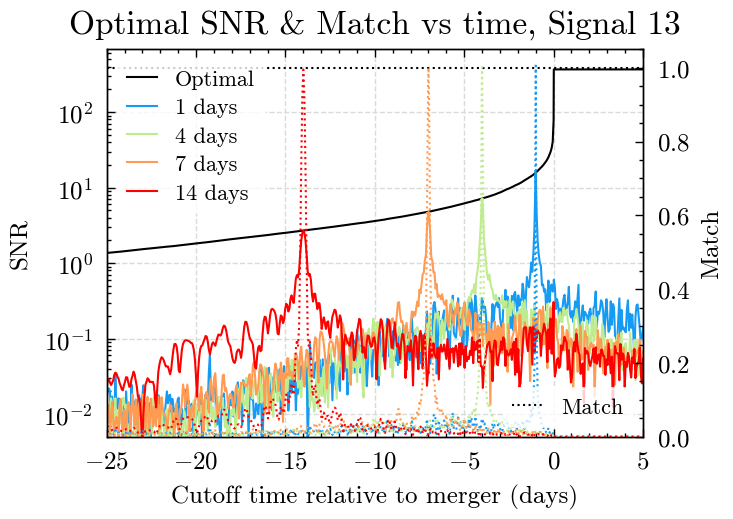

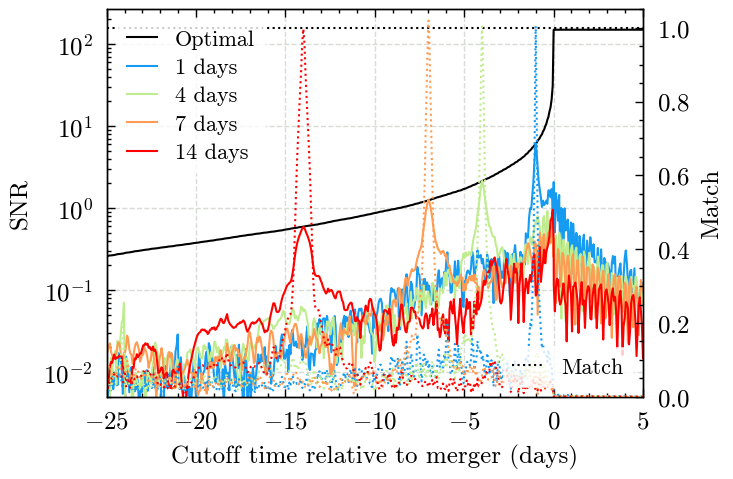

In [ ]:
optimal_snr_over_time = {}
for signal_number in range(len(mbhb_sky)):
    if signal_number not in ff_results['optimal_snr']:
        continue
    print(signal_number)
    if signal_number == 14:
        title = 'off'
    else:
        title = None
    fig, (ax, ax2) = plot_optimal_snr_match(
        ff_results['cutoff_days'],
        ff_results['optimal_snr'][signal_number],
        ff_results['match_cut'][signal_number],
        signal_number=signal_number,
        title=title
    )
    if signal_number == 14:
        output_fname = '../../paper/images/zero_latency_results/figure_4_opt_snr_match_signal_14.pdf'
        print("Outputting to %s" % output_fname)
        fig.savefig(output_fname)
